# Semantic deduplication of Portuguese exam questions

This experiment compares embeddings and calibrates the duplicate threshold on the
**466 LLM-annotated pairs** in `manual_labels_llm_annotated.csv`. Selection uses MCC
with nested grouped cross-validation. No questions are removed from the corpus.

We address two separate questions: (1) does cosine similarity distinguish duplicate
questions from merely related ones? (2) do NeMo Curator clustering and ordering change
the candidates and items marked for removal? The first is evaluated against labels;
the second is a descriptive diagnostic on this sample.

## 1. Literature and experimental decisions

- **[SemDeDup — Abbas et al., 2023](https://arxiv.org/abs/2303.09540):** clusters
  embeddings and compares items within clusters. Redundancy reduction for pretraining
  does not automatically establish strict equivalence between MCQA questions.
- **[mGTE — Zhang et al., 2024](https://arxiv.org/abs/2407.19669):** multilingual
  encoder with an 8,192-token context. We use `gte-multilingual-base` without a prefix
  and with dense representations only. On MTEB-PT, it scored 80.4 on STS and 76.9 on
  retrieval, compared with 79.2 and 73.4 for E5-large. This motivates its inclusion
  without establishing superiority for MCQA deduplication. E5 was excluded because
  of its 512-token limit.
- **[BGE-M3 — Chen et al., 2024](https://arxiv.org/abs/2402.03216):** multilingual
  model with a long context; we use dense embeddings only, without a prefix.
- **[Qwen3 Embedding — Zhang et al., 2025](https://arxiv.org/abs/2506.05176):**
  higher-capacity, instruction-conditioned encoder. We use 4B and 8B at full dimensionality,
  with the same English instruction for both items. This symmetric instruction is
  an experimental choice, not an MCQA protocol validated by the paper.
- **[Llama-Embed-Nemotron-8B — Babakhin et al., 2025](https://arxiv.org/abs/2511.07025):**
  multilingual encoder with bidirectional attention and mean pooling. We use its
  documented 32,768-token limit and full 4,096 dimensions. Both items receive the
  same task instruction as Qwen; this symmetric MCQA protocol is an experimental
  choice, not the model card's asymmetric retrieval example. The released model
  is intended for non-commercial research.
- **[MTEB-PT — Okamura et al., 2026](https://arxiv.org/abs/2607.04071)** and
  **[MTEB-BR — Stekel, 2026](https://arxiv.org/abs/2607.04581):** highlight the need
  for Portuguese and task-specific evaluation. Retrieval or STS rankings do not
  determine the best deduplication model for this sample.

| Model | Dimensions | Token limit | Input |
|---|---:|---:|---|
| `BAAI/bge-m3` | 1024 | 8192 | no prefix |
| `Alibaba-NLP/gte-multilingual-base` | 768 | 8192 | no prefix |
| `Octen/Octen-Embedding-0.6B` | 1024 | 32768 | symmetric `- ` prefix |
| `Octen/Octen-Embedding-4B` | 2560 | 32768 | symmetric `- ` prefix |
| `Octen/Octen-Embedding-8B` | 4096 | 32768 | symmetric `- ` prefix |
| `nvidia/Nemotron-3-Embed-1B-BF16` | 2048 | 32768 | symmetric `passage: ` prefix |
| `nvidia/Nemotron-3-Embed-8B-BF16` | 4096 | 32768 | symmetric `passage: ` prefix |
| `Qwen/Qwen3-Embedding-4B` | 2560 | 32768 | symmetric instruction |
| `Qwen/Qwen3-Embedding-8B` | 4096 | 32768 | symmetric instruction |
| `nvidia/llama-embed-nemotron-8b` | 4096 | 32768 | symmetric instruction |

All three Octen models use last-token pooling and the same symmetric `- ` prefix,
extending the existing 8B protocol to 0.6B and 4B. We cap all three at 32,768 tokens.
Nemotron 3 uses bidirectional attention and mean pooling. Both items use `passage: `
because they are exam documents; this symmetric use is an experimental choice rather
than the model cards' asymmetric query/passage retrieval protocol.

Additional model references: [Octen 0.6B](https://huggingface.co/Octen/Octen-Embedding-0.6B),
[Octen 4B](https://huggingface.co/Octen/Octen-Embedding-4B), [Octen 8B](https://huggingface.co/Octen/Octen-Embedding-8B),
[Nemotron 3 1B](https://huggingface.co/nvidia/Nemotron-3-Embed-1B-BF16),
[Nemotron 3 8B](https://huggingface.co/nvidia/Nemotron-3-Embed-8B-BF16), and
[Qwen3 4B](https://huggingface.co/Qwen/Qwen3-Embedding-4B).

Implementation references: [BGE-M3](https://huggingface.co/BAAI/bge-m3),
[GTE multilingual](https://huggingface.co/Alibaba-NLP/gte-multilingual-base),
[Qwen3](https://huggingface.co/Qwen/Qwen3-Embedding-8B),
[Nemotron](https://huggingface.co/nvidia/llama-embed-nemotron-8b), and
[NeMo Curator](https://docs.nvidia.com/nemo/curator/curate-text/process-data/deduplication/semdedup).
The APIs below were checked against the installed NeMo Curator **1.3.0** source.

## 2. Configuration and environment

Use the project environment: `uv sync --group notebook`. An NVIDIA GPU is required
to recompute embeddings, MinHash, and the NeMo workflow. Models load sequentially;
caches allow execution to resume. `RUN_COMPUTE=False` reproduces the analyses from
cached results without initializing CUDA or downloading models. Hashes include
the data, protocol, and versions; changes invalidate the cache.

The original questions and answer choices remain in Portuguese throughout the analysis.

All run artifacts are saved under `notebooks/output/semantic-deduplication-ablation/<run hash>/`,
resolved from the repository root regardless of the execution directory.


In [1]:
from __future__ import annotations

import gc
import hashlib
import importlib.metadata
import json
import os
import platform
import time
import unicodedata
from datetime import datetime, timezone
from pathlib import Path

os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from matplotlib.lines import Line2D
from sklearn.model_selection import StratifiedGroupKFold

from mmlu_pt.pipelines.fuzzy import (
    CHAR_NGRAMS, JACCARD_THRESHOLD, MIN_MATCHING_BANDS, PARAMETERS,
    compute_signatures, jaccard, matching_bands, serialize_fuzzy_text,
)

RUN_COMPUTE = True
SEED = 42
CV_SEED = 20260911
OUTER_SPLITS, OUTER_REPEATS, INNER_SPLITS = 5, 10, 4
CLUSTER_COUNTS = (1, 8, 32)
REPRESENTATIONS = ("question", "question_choices")
TASK_INSTRUCTION = (
    "Identify exam questions that assess the same task and require the same substantive "
    "answer, distinguishing material changes in conditions, quantities, or assessment target."
)
MODELS = [
    {"model": "BAAI/bge-m3", "max_length": 8192, "batch_size": 16,
     "prefix": "", "dimension": 1024},
    {"model": "Alibaba-NLP/gte-multilingual-base", "max_length": 8192, "batch_size": 16,
     "prefix": "", "dimension": 768, "code_repo": "Alibaba-NLP/new-impl"},
    {"model": "Octen/Octen-Embedding-0.6B", "max_length": 32768, "batch_size": 16,
     "prefix": "- ", "dimension": 1024, "padding_side": "left"},
    {"model": "Octen/Octen-Embedding-4B", "max_length": 32768, "batch_size": 4,
     "prefix": "- ", "dimension": 2560, "padding_side": "left"},
    {"model": "Octen/Octen-Embedding-8B", "max_length": 32768, "batch_size": 4,
     "prefix": "- ", "dimension": 4096, "padding_side": "left"},
    {"model": "nvidia/Nemotron-3-Embed-1B-BF16", "max_length": 32768, "batch_size": 8,
     "prefix": "passage: ", "dimension": 2048, "padding_side": "left",
     "isolated_transformers": "5.2.0", "isolated_tokenizers": "0.22.2",
     "isolated_huggingface_hub": "1.4.1", "pooling": "mean_float32"},
    {"model": "nvidia/Nemotron-3-Embed-8B-BF16", "max_length": 32768, "batch_size": 4,
     "prefix": "passage: ", "dimension": 4096, "padding_side": "left",
     "isolated_transformers": "5.2.0", "isolated_tokenizers": "0.22.2",
     "isolated_huggingface_hub": "1.4.1", "pooling": "mean_float32"},
    {"model": "Qwen/Qwen3-Embedding-4B", "max_length": 32768, "batch_size": 4,
     "prefix": f"Instruct: {TASK_INSTRUCTION}\nQuery: ", "dimension": 2560},
    {"model": "Qwen/Qwen3-Embedding-8B", "max_length": 32768, "batch_size": 4,
     "prefix": f"Instruct: {TASK_INSTRUCTION}\nQuery: ", "dimension": 4096},
    {"model": "nvidia/llama-embed-nemotron-8b", "max_length": 32768, "batch_size": 4,
     "prefix": f"Instruct: {TASK_INSTRUCTION}\nQuery: ", "dimension": 4096,
     "code_repo": "nvidia/llama-embed-nemotron-8b", "padding_side": "left",
     "isolated_transformers": "4.51.0", "isolated_tokenizers": "0.21.4",
     "pooling": "mean_float32"},
]

REPO_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").is_file())
ANNOTATION_PATH = REPO_ROOT / "assets/annotations/manual_labels_llm_annotated.csv"
VERSIONS = {name: importlib.metadata.version(name) for name in (
    "nemo-curator", "torch", "transformers", "sentence-transformers", "scikit-learn",
    "numpy", "pandas", "pyarrow", "ray", "cuml-cu12",
)}
assert VERSIONS["nemo-curator"] == "1.3.0", "Revalidate the API before changing the NeMo version."


def digest(value) -> str:
    return hashlib.sha256(json.dumps(value, ensure_ascii=False, sort_keys=True).encode()).hexdigest()


def read_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8"))


def write_json(path: Path, value) -> None:
    path.write_text(json.dumps(value, ensure_ascii=False, indent=2, allow_nan=False), encoding="utf-8")


ANNOTATION_SHA256 = hashlib.sha256(ANNOTATION_PATH.read_bytes()).hexdigest()
SPEC = {
    "protocol": "semantic-mcqa-v1", "models": MODELS, "representations": REPRESENTATIONS,
    "seed": SEED, "cv_seed": CV_SEED, "outer_splits": OUTER_SPLITS,
    "outer_repeats": OUTER_REPEATS, "inner_splits": INNER_SPLITS,
    "clusters": CLUSTER_COUNTS, "versions": VERSIONS, "fuzzy": PARAMETERS,
    "annotation_sha256": ANNOTATION_SHA256,
    "nemotron_encoder_sha256": hashlib.sha256((REPO_ROOT / "notebooks/nemotron_embeddings.py").read_bytes()).hexdigest(),
}
ARTIFACT_ROOT = REPO_ROOT / "notebooks/output/semantic-deduplication-ablation" / digest(SPEC)[:20]
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 110)
display(pd.Series(VERSIONS, name="version").to_frame())
print(f"Artifacts: {ARTIFACT_ROOT}")

,version
nemo-curator,1.3.0
torch,2.9.1
transformers,4.57.6
sentence-transformers,5.6.1
scikit-learn,1.7.2
numpy,2.2.6
pandas,2.3.3
pyarrow,25.0.0
ray,2.56.1
cuml-cu12,25.10.0


Artifacts: /home/aluno_paulosantana/repositories/mmlu-pt/notebooks/output/semantic-deduplication-ablation/7e16f8554e7fb8462646


## 3. Pairs, representations, and groups without shared inputs

`duplicate` is positive; `related_but_distinct` and `distinct` are negative. This
version contains no `unsure` labels. Unexpected labels or invalid inputs stop the
analysis. Answer keys, notes, and sampling metadata are excluded from selection.

Embeddings preserve case, accents, numbers, negation, and answer-choice order.
We apply NFKC normalization and collapse whitespace. Full item IDs use the fuzzy
analysis normalization to keep the 837 items comparable. Groups connect shared
items and identical normalized question texts, even when their choices differ;
this prevents the question-only ablation from sharing inputs across training and evaluation.

In [2]:
columns = ["pair_key", "left_question", "left_choices", "right_question", "right_choices", "label"]
pairs = pd.read_csv(ANNOTATION_PATH, usecols=columns, keep_default_na=False)
assert len(pairs) == pairs.pair_key.nunique() == 466
assert pairs.label.value_counts().to_dict() == {"related_but_distinct": 279, "duplicate": 185, "distinct": 2}


def clean_text(text: str) -> str:
    return " ".join(unicodedata.normalize("NFKC", text).split())


def parse_choices(raw: str) -> list[str]:
    choices = json.loads(raw)
    if not isinstance(choices, list) or not choices or not all(isinstance(x, str) and x.strip() for x in choices):
        raise ValueError("Answer choices must be a JSON list of nonempty strings.")
    return choices


records = {}
for side in ("left", "right"):
    ids = []
    for question, raw_choices in zip(pairs[f"{side}_question"], pairs[f"{side}_choices"], strict=True):
        assert question.strip()
        choices = parse_choices(raw_choices)
        lexical_text = serialize_fuzzy_text(question, choices)
        item_id = digest(lexical_text)
        ids.append(item_id)
        full_text = clean_text(question + "\n" + "\n".join(
            f"[{chr(65 + i)}] {choice}" for i, choice in enumerate(choices)))
        # Case/whitespace variants share an ID; choose the text deterministically.
        record = {"id": item_id, "question": clean_text(question),
                  "question_choices": full_text, "lexical_text": lexical_text}
        if item_id not in records or full_text < records[item_id]["question_choices"]:
            records[item_id] = record
    pairs[f"{side}_id"] = ids
items = pd.DataFrame(sorted(records.values(), key=lambda row: row["id"]))
assert len(items) == 837
item_index = {item_id: i for i, item_id in enumerate(items.id)}
left_index = pairs.left_id.map(item_index).to_numpy()
right_index = pairs.right_id.map(item_index).to_numpy()
y = pairs.label.eq("duplicate").to_numpy()

parent = {item_id: item_id for item_id in items.id}


def root(item_id: str) -> str:
    while parent[item_id] != item_id:
        parent[item_id] = parent[parent[item_id]]
        item_id = parent[item_id]
    return item_id


def union(left: str, right: str) -> None:
    a, b = sorted((root(left), root(right)))
    parent[b] = a


for left, right in zip(pairs.left_id, pairs.right_id, strict=True):
    union(left, right)
for _, shared in items.groupby(items.question.str.casefold(), sort=True):
    for item_id in shared.id:
        union(shared.id.iloc[0], item_id)
pairs["group_id"] = pairs.left_id.map(root)
assert np.array_equal(pairs.group_id, pairs.right_id.map(root))
groups = pairs.group_id.to_numpy()
items.to_parquet(ARTIFACT_ROOT / "items.parquet", index=False)
pairs.to_parquet(ARTIFACT_ROOT / "pairs.parquet", index=False)
display(pairs.label.value_counts().rename_axis("label").to_frame("pairs"))
print(f"{len(items)} items; {pairs.group_id.nunique()} evaluation groups.")

,pairs
label,
related_but_distinct,279
duplicate,185
distinct,2


837 items; 373 evaluation groups.


## 4. Reproducible embeddings and truncation

Each model is resolved to a Hugging Face commit, and that revision is saved before
inference. Subsequent runs use the same commit. The revision, IDs, and protocol
identify the cache. We use BF16 on the GPU, float32 output, and explicit L2 normalization.
Pooling follows the model configuration in Sentence Transformers; Qwen, Octen, and all Nemotron variants use left padding.
GTE requires `trust_remote_code=True`: we also pin the commit of `Alibaba-NLP/new-impl`,
used by its official configuration. It uses eager attention without requiring xformers;
All Nemotron variants use eager attention; BGE, Qwen, and Octen use SDPA. Embedding dimensions are unchanged.

Each model uses the token limit documented in the table above. We count tokens **including the prefix**
before truncation and record every affected item. The main analysis does not use
chunking or drop long pairs; a separate descriptive comparison uses the common
subset without truncation.

Llama-Embed-Nemotron runs through `notebooks/nemotron_embeddings.py` in a subprocess with
Transformers 4.51.0 (the model card's supported version) and tokenizers 0.21.4.
`uv` installs these two packages into a temporary directory without changing the
project environment. The existing Torch/CUDA stack is shared. This avoids changes
to Llama's attention implementation in newer Transformers releases. The helper
uses the official remote model, eager bidirectional attention, left padding, and
float32 masked mean pooling including instruction tokens, followed by L2 normalization.
A runtime check verifies attention to future real tokens and zero attention to
padding keys. The helper's hash and runtime versions are recorded with the results.

Nemotron 3 uses the same helper with native Transformers 5.2.0, tokenizers 0.22.2,
and Hugging Face Hub 1.4.1 in the isolated directory. Hub dependencies are installed
there as well; the project environment is unchanged. Both Nemotron 3 sizes use
float32 masked mean pooling including prefix tokens and the same attention checks.
The older Llama remote implementation is not used for these models.


In [3]:
from huggingface_hub import HfApi

revision_path = ARTIFACT_ROOT / "model_revisions.json"
revisions = read_json(revision_path) if revision_path.exists() else {}
revision_repos = sorted({spec["model"] for spec in MODELS} | {spec["code_repo"] for spec in MODELS if "code_repo" in spec})
for repo in revision_repos:
    if repo not in revisions:
        if not RUN_COMPUTE:
            raise FileNotFoundError(f"Missing revision: {revision_path}; run with RUN_COMPUTE=True.")
        revisions[repo] = HfApi().model_info(repo).sha
        write_json(revision_path, revisions)

embedding_paths, token_tables, timings, score_columns = {}, [], [], {}
gpu_description = "cache; GPU not initialized"
for spec in MODELS:
    model = None
    for representation in REPRESENTATIONS:
        slug = spec["model"].split("/")[-1] + "__" + representation
        identity = digest({"spec": SPEC, "revision": revisions[spec["model"]],
                           "code_revision": revisions.get(spec.get("code_repo")),
                           "slug": slug, "ids": items.id.tolist()})
        cache_dir = ARTIFACT_ROOT / "embeddings" / identity[:20]
        cache_dir.mkdir(parents=True, exist_ok=True)
        embedding_path, info_path = cache_dir / "embeddings.npy", cache_dir / "info.json"
        token_path = cache_dir / "tokens.parquet"
        if "isolated_transformers" in spec and not all(p.exists() for p in (embedding_path, info_path, token_path)):
            if not RUN_COMPUTE:
                raise FileNotFoundError(f"Incomplete cache for {slug}; run with RUN_COMPUTE=True.")
            import subprocess
            import sys
            import tempfile

            # Isolate only Transformers/tokenizers; keep the project's Torch/CUDA stack.
            with tempfile.TemporaryDirectory(prefix="nemotron-runtime-") as temporary:
                runtime = Path(temporary)
                subprocess.run([
                    "uv", "pip", "install", "--target", str(runtime / "packages"), "--no-deps",
                    f"transformers=={spec['isolated_transformers']}",
                    f"tokenizers=={spec['isolated_tokenizers']}",
                ], check=True)
                if "isolated_huggingface_hub" in spec:
                    subprocess.run([
                        "uv", "pip", "install", "--target", str(runtime / "packages"),
                        f"huggingface-hub=={spec['isolated_huggingface_hub']}",
                    ], check=True)
                request_path = runtime / "request.json"
                write_json(request_path, {
                    "spec": spec, "revision": revisions[spec["model"]], "seed": SEED,
                    "identity": identity, "slug": slug, "representation": representation,
                    "texts": items[representation].tolist(), "ids": items.id.tolist(),
                    "output": str(cache_dir),
                })
                environment = {**os.environ, "PYTHONPATH": str(runtime / "packages")}
                subprocess.run([sys.executable, str(REPO_ROOT / "notebooks/nemotron_embeddings.py"),
                                str(request_path)], env=environment, check=True)
            info = read_json(cache_dir / "isolated_result.json")
            tokens = pd.DataFrame({"id": info["ids"], "tokens": info.pop("tokens")})
            tokens["truncated"] = tokens.tokens > spec["max_length"]
            tokens.to_parquet(token_path, index=False)
            write_json(info_path, info)
        if not all(p.exists() for p in (embedding_path, info_path, token_path)):
            if not RUN_COMPUTE:
                raise FileNotFoundError(f"Incomplete cache for {slug}; run with RUN_COMPUTE=True.")
            import torch
            from sentence_transformers import SentenceTransformer

            if not torch.cuda.is_available():
                raise RuntimeError("CUDA unavailable; run on a GPU or use complete caches.")
            gpu_description = torch.cuda.get_device_name(0)
            if model is None:
                torch.manual_seed(SEED)
                model_kwargs = {"torch_dtype": torch.bfloat16, "attn_implementation": "sdpa"}
                config_kwargs = {}
                if "code_repo" in spec:
                    model_kwargs.update(code_revision=revisions[spec["code_repo"]], attn_implementation="eager")
                    config_kwargs["code_revision"] = revisions[spec["code_repo"]]
                model = SentenceTransformer(
                    spec["model"], revision=revisions[spec["model"]], device="cuda",
                    trust_remote_code="code_repo" in spec,
                    model_kwargs=model_kwargs, config_kwargs=config_kwargs,
                    tokenizer_kwargs={"padding_side": spec.get("padding_side", "left" if "Qwen" in spec["model"] else "right")},
                )
                model.max_seq_length = spec["max_length"]
                model.eval()
            texts = items[representation].tolist()
            lengths = []
            for start in range(0, len(texts), 64):
                encoded = model.tokenizer([spec["prefix"] + text for text in texts[start:start + 64]],
                                          truncation=False, padding=False, verbose=False)
                lengths.extend(map(len, encoded["input_ids"]))
            tokens = pd.DataFrame({"id": items.id, "tokens": lengths})
            tokens["truncated"] = tokens.tokens > spec["max_length"]
            torch.cuda.reset_peak_memory_stats()
            started = time.perf_counter()
            embeddings = model.encode(
                texts, prompt=spec["prefix"], batch_size=spec["batch_size"],
                normalize_embeddings=False, convert_to_numpy=True, show_progress_bar=True,
            ).astype(np.float32)
            embeddings /= np.linalg.norm(embeddings, axis=1, keepdims=True)
            torch.cuda.synchronize()
            elapsed = time.perf_counter() - started
            np.save(embedding_path, embeddings)
            tokens.to_parquet(token_path, index=False)
            write_json(info_path, {"identity": identity, "slug": slug, "model": spec["model"],
                "revision": revisions[spec["model"]], "code_revision": revisions.get(spec.get("code_repo")),
                "representation": representation,
                "seconds": elapsed, "peak_gpu_gib": torch.cuda.max_memory_allocated() / 2**30,
                "gpu": gpu_description, "ids": items.id.tolist()})
        embeddings = np.load(embedding_path, allow_pickle=False)
        info, tokens = read_json(info_path), pd.read_parquet(token_path)
        assert info["identity"] == identity and info["ids"] == items.id.tolist()
        if "isolated_transformers" in spec:
            assert info["transformers"] == spec["isolated_transformers"]
            assert info["tokenizers"] == spec["isolated_tokenizers"]
            if "isolated_huggingface_hub" in spec:
                assert info["huggingface_hub"] == spec["isolated_huggingface_hub"]
            assert info["bidirectional_attention_verified"]
        assert tokens.id.tolist() == items.id.tolist()
        assert embeddings.shape == (len(items), spec["dimension"])
        assert np.isfinite(embeddings).all()
        assert np.allclose(np.linalg.norm(embeddings, axis=1), 1, atol=1e-5)
        score_columns[slug] = np.clip(np.einsum("ij,ij->i", embeddings[left_index], embeddings[right_index]), -1, 1).astype(float)
        embedding_paths[slug] = embedding_path
        token_tables.append(tokens.assign(configuration=slug))
        timings.append({key: info[key] for key in ("slug", "seconds", "peak_gpu_gib", "gpu")})
        print(f"{slug}: {tokens.truncated.sum()} / {len(tokens)} truncated items", flush=True)
    if model is not None:
        del model
        gc.collect()
        torch.cuda.empty_cache()

scores = pd.DataFrame(score_columns)
scores.insert(0, "pair_key", pairs.pair_key)
scores.to_parquet(ARTIFACT_ROOT / "pair_scores.parquet", index=False)
token_audit = pd.concat(token_tables, ignore_index=True)
token_audit.to_parquet(ARTIFACT_ROOT / "token_audit.parquet", index=False)
runtime_table = pd.DataFrame(timings)
runtime_table.to_csv(ARTIFACT_ROOT / "embedding_runtime.csv", index=False)
display(runtime_table)
display(token_audit.groupby("configuration").agg(
    max_tokens=("tokens", "max"), truncated_items=("truncated", "sum")))

The `tokenizer_kwargs` argument was renamed and is now deprecated. Please use `processor_kwargs` instead.


`torch_dtype` is deprecated! Use `dtype` instead!


Batches:   0%|          | 0/53 [00:00<?, ?it/s]

bge-m3__question: 0 / 837 truncated items


Batches:   0%|          | 0/53 [00:00<?, ?it/s]

...

Loading checkpoint shards: 100%|██████████| 4/4 [00:00<00:00, 185.18it/s]


llama-embed-nemotron-8b__question_choices: official attention checks passed; inference 32.5 s.


llama-embed-nemotron-8b__question_choices: 0 / 837 truncated items


,slug,seconds,peak_gpu_gib,gpu
0,bge-m3__question,2.968625,1.799457,NVIDIA B200
1,bge-m3__question_choices,2.447631,1.874972,NVIDIA B200
2,gte-multilingual-base__question,3.560317,3.494584,NVIDIA B200
3,gte-multilingual-base__question_choices,3.680678,4.000012,NVIDIA B200
4,Octen-Embedding-0.6B__question,5.579052,5.492098,NVIDIA B200
5,Octen-Embedding-0.6B__question_choices,5.879618,5.914424,NVIDIA B200
6,Octen-Embedding-4B__question,14.071479,9.293009,NVIDIA B200
7,Octen-Embedding-4B__question_choices,14.809640,9.453980,NVIDIA B200
8,Octen-Embedding-8B__question,15.754797,16.059174,NVIDIA B200
9,Octen-Embedding-8B__question_choices,17.588767,16.238036,NVIDIA B200


,max_tokens,truncated_items
configuration,,
Nemotron-3-Embed-1B-BF16__question,1866,0
Nemotron-3-Embed-1B-BF16__question_choices,2049,0
Nemotron-3-Embed-8B-BF16__question,1866,0
Nemotron-3-Embed-8B-BF16__question_choices,2049,0
Octen-Embedding-0.6B__question,2039,0
Octen-Embedding-0.6B__question_choices,2230,0
Octen-Embedding-4B__question,2039,0
Octen-Embedding-4B__question_choices,2230,0
Octen-Embedding-8B__question,2039,0


## 5. Lexical baseline and metrics

The baseline uses the current pipeline's exact MinHash/LSH and Jaccard configuration,
applied to each pair without component propagation. This configuration was previously
selected on the same sample: the comparison is descriptive, not an independent test.
Precision with no positive predictions is undefined and shown as `NaN`; undefined
precision is treated as zero when breaking selection ties. Degenerate MCC is zero.

In [4]:
def metrics(labels: np.ndarray, predictions: np.ndarray) -> dict:
    labels, predictions = np.asarray(labels, dtype=bool), np.asarray(predictions, dtype=bool)
    tp = int(np.sum(labels & predictions))
    fp = int(np.sum(~labels & predictions))
    tn = int(np.sum(~labels & ~predictions))
    fn = int(np.sum(labels & ~predictions))
    denominator = float((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)) ** 0.5
    return {"tp": tp, "fp": fp, "tn": tn, "fn": fn,
            "precision": tp / (tp + fp) if tp + fp else np.nan,
            "recall": tp / (tp + fn) if tp + fn else np.nan,
            "f1": 2 * tp / (2 * tp + fp + fn) if 2 * tp + fp + fn else 0.0,
            "mcc": (tp * tn - fp * fn) / denominator if denominator else 0.0}


fuzzy_path = ARTIFACT_ROOT / "fuzzy_reference.parquet"
if not fuzzy_path.exists():
    if not RUN_COMPUTE:
        raise FileNotFoundError(f"Missing fuzzy baseline: {fuzzy_path}")
    signatures, fuzzy_gpu = compute_signatures(items.lexical_text.tolist())
    shingles = [{text[i:i + CHAR_NGRAMS] for i in range(len(text) - CHAR_NGRAMS + 1)}
                for text in items.lexical_text]
    fuzzy = pd.DataFrame({"pair_key": pairs.pair_key,
        "matching_bands": [matching_bands(signatures[a], signatures[b]) for a, b in zip(left_index, right_index)],
        "jaccard": [jaccard(shingles[a], shingles[b]) for a, b in zip(left_index, right_index)]})
    fuzzy["prediction"] = (fuzzy.matching_bands >= MIN_MATCHING_BANDS) & (fuzzy.jaccard >= JACCARD_THRESHOLD)
    fuzzy.to_parquet(fuzzy_path, index=False)
fuzzy = pd.read_parquet(fuzzy_path)
assert fuzzy.pair_key.tolist() == pairs.pair_key.tolist()
display(pd.DataFrame([metrics(y, fuzzy.prediction)], index=["previously selected fuzzy baseline"]))

,tp,fp,tn,fn,precision,recall,f1,mcc
previously selected fuzzy baseline,128,6,275,57,0.955224,0.691892,0.802508,0.72484


## 6. Nested grouped selection

Within each outer training split, four inner folds select **model + representation**.
For each inner fold, the threshold is fitted exclusively on that fold's training
split, using midpoints between consecutive scores and including all/none decisions.
The best model/representation maximizes mean inner-validation MCC; its threshold
is then refitted on the entire outer training split and applied to the outer test split.

Ties are broken by precision, recall, and identifier; tied thresholds favor the larger value.
Each outer repetition produces one out-of-sample prediction per pair.
The final recommendation uses four grouped folds on all data, followed by threshold
fitting on the full panel. Its full-panel metrics are **descriptive**.
Standard deviations across repetitions measure sensitivity to splits, not confidence intervals.

In [5]:
configurations = sorted(score_columns)
score_matrix = scores[configurations].to_numpy()


def assert_disjoint(train: np.ndarray, test: np.ndarray) -> None:
    assert not set(groups[train]) & set(groups[test])
    train_items = set(pairs.iloc[train].left_id) | set(pairs.iloc[train].right_id)
    test_items = set(pairs.iloc[test].left_id) | set(pairs.iloc[test].right_id)
    assert not train_items & test_items


def best_threshold(values: np.ndarray, labels: np.ndarray) -> float:
    unique = np.unique(values)
    thresholds = np.r_[np.nextafter(unique[0], -np.inf),
                       (unique[:-1] + unique[1:]) / 2,
                       np.nextafter(unique[-1], np.inf)]
    predictions = values[None, :] >= thresholds[:, None]
    tp = np.sum(predictions & labels, axis=1).astype(float)
    fp = np.sum(predictions & ~labels, axis=1).astype(float)
    fn, tn = labels.sum() - tp, (~labels).sum() - fp
    denominator = np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    mcc = np.divide(tp * tn - fp * fn, denominator, out=np.zeros_like(tp), where=denominator != 0)
    precision = np.divide(tp, tp + fp, out=np.zeros_like(tp), where=(tp + fp) != 0)
    recall = tp / labels.sum()
    index = np.lexsort((thresholds, recall, precision, mcc))[-1]
    return float(thresholds[index])


def select_configuration(indices: np.ndarray, seed: int) -> tuple[str, float, pd.DataFrame]:
    splitter = StratifiedGroupKFold(INNER_SPLITS, shuffle=True, random_state=seed)
    rows = []
    for fold, (train_local, validation_local) in enumerate(splitter.split(indices, y[indices], groups[indices])):
        train, validation = indices[train_local], indices[validation_local]
        assert_disjoint(train, validation)
        assert len(np.unique(y[train])) == len(np.unique(y[validation])) == 2
        for column, slug in enumerate(configurations):
            threshold = best_threshold(score_matrix[train, column], y[train])
            rows.append({"configuration": slug, "fold": fold, "threshold": threshold,
                         **metrics(y[validation], score_matrix[validation, column] >= threshold)})
    ranking = pd.DataFrame(rows).fillna({"precision": 0.0}).groupby("configuration", as_index=False)[["mcc", "precision", "recall"]].mean()
    ranking = ranking.fillna(0).sort_values(["mcc", "precision", "recall", "configuration"],
                                           ascending=[False, False, False, True])
    selected = ranking.iloc[0].configuration
    threshold = best_threshold(score_matrix[indices, configurations.index(selected)], y[indices])
    return selected, threshold, ranking


outer_rows, prediction_rows, fold_rows, per_model_rows = [], [], [], []
indices = np.arange(len(pairs))
for repeat in range(OUTER_REPEATS):
    splitter = StratifiedGroupKFold(OUTER_SPLITS, shuffle=True, random_state=CV_SEED + repeat)
    for fold, (train, test) in enumerate(splitter.split(indices, y, groups)):
        assert_disjoint(train, test)
        assert len(np.unique(y[train])) == len(np.unique(y[test])) == 2
        slug, threshold, _ = select_configuration(train, CV_SEED + 1000 + repeat * OUTER_SPLITS + fold)
        predictions = score_matrix[test, configurations.index(slug)] >= threshold
        outer_rows.append({"repeat": repeat, "fold": fold, "configuration": slug,
                           "threshold": threshold, **metrics(y[test], predictions)})
        for index, prediction in zip(test, predictions, strict=True):
            prediction_rows.append({"repeat": repeat, "fold": fold, "pair_key": pairs.pair_key.iloc[index],
                                    "label": bool(y[index]), "prediction": bool(prediction),
                                    "configuration": slug, "threshold": threshold})
        for index in test:
            fold_rows.append({"repeat": repeat, "fold": fold, "pair_key": pairs.pair_key.iloc[index],
                              "group_id": groups[index]})
        # Compare each treatment using a threshold fitted on outer training data, without test-based selection.
        for column, treatment in enumerate(configurations):
            treatment_threshold = best_threshold(score_matrix[train, column], y[train])
            for index in test:
                per_model_rows.append({"repeat": repeat, "pair_key": pairs.pair_key.iloc[index],
                    "configuration": treatment, "label": bool(y[index]),
                    "prediction": bool(score_matrix[index, column] >= treatment_threshold)})

outer_results = pd.DataFrame(outer_rows)
outer_predictions = pd.DataFrame(prediction_rows)
assert outer_predictions.groupby(["repeat", "pair_key"]).size().eq(1).all()
assert len(outer_predictions) == OUTER_REPEATS * len(pairs)
repeat_metrics = pd.DataFrame([{"repeat": repeat, **metrics(frame.label, frame.prediction)}
    for repeat, frame in outer_predictions.groupby("repeat")])
treatment_predictions = pd.DataFrame(per_model_rows)
treatment_metrics = pd.DataFrame([{"repeat": repeat, "configuration": slug,
    **metrics(frame.label, frame.prediction)}
    for (repeat, slug), frame in treatment_predictions.groupby(["repeat", "configuration"])])
selected_slug, selected_threshold, final_ranking = select_configuration(indices, CV_SEED + 10000)
selected_scores = scores[selected_slug].to_numpy()
selected_predictions = selected_scores >= selected_threshold
for name, frame in {
    "outer_folds": outer_results, "outer_predictions": outer_predictions,
    "fold_assignments": pd.DataFrame(fold_rows), "repeat_metrics": repeat_metrics,
    "treatment_predictions": treatment_predictions, "treatment_metrics": treatment_metrics,
    "final_inner_ranking": final_ranking,
}.items():
    frame.to_parquet(ARTIFACT_ROOT / f"{name}.parquet", index=False)
write_json(ARTIFACT_ROOT / "selected_configuration.json", {
    "configuration": selected_slug, "threshold": selected_threshold, "eps": 1 - selected_threshold,
    "selection": "mean inner grouped-CV MCC; final threshold fitted on all pairs",
})
display(Markdown(f"**Provisional recommendation:** `{selected_slug}`; cosine ≥ **{selected_threshold:.6f}**."))
display(repeat_metrics[["mcc", "precision", "recall", "f1"]].agg(["mean", "std", "min", "max"]))
display(treatment_metrics.groupby("configuration")[["mcc", "precision", "recall", "f1"]].mean().sort_values("mcc", ascending=False))
display(final_ranking)

**Provisional recommendation:** `Octen-Embedding-8B__question_choices`; cosine ≥ **0.973705**.

,mcc,precision,recall,f1
mean,0.954798,0.960121,0.985946,0.972823
std,0.010155,0.010976,0.005811,0.006104
min,0.934559,0.933673,0.972973,0.960630
max,0.964429,0.968254,0.989189,0.978610


,mcc,precision,recall,f1
configuration,,,,
Octen-Embedding-8B__question_choices,0.959103,0.964594,0.986486,0.975408
Qwen3-Embedding-8B__question_choices,0.919886,0.915594,0.990811,0.951701
llama-embed-nemotron-8b__question_choices,0.906303,0.909727,0.980541,0.943803
Octen-Embedding-4B__question_choices,0.900676,0.936226,0.944324,0.940247
Qwen3-Embedding-8B__question,0.866580,0.875217,0.970270,0.920270
Octen-Embedding-8B__question,0.859171,0.904523,0.927027,0.915603
Nemotron-3-Embed-8B-BF16__question_choices,0.855277,0.859408,0.974595,0.913331
Qwen3-Embedding-4B__question_choices,0.811886,0.882167,0.891892,0.886869
Qwen3-Embedding-4B__question,0.788645,0.871704,0.873514,0.872475


,configuration,mcc,precision,recall
9,Octen-Embedding-8B__question_choices,0.960147,0.964727,0.989357
13,Qwen3-Embedding-8B__question_choices,0.909438,0.915580,0.981818
19,llama-embed-nemotron-8b__question_choices,0.907967,0.910346,0.983405
7,Octen-Embedding-4B__question_choices,0.905821,0.937159,0.952399
3,Nemotron-3-Embed-8B-BF16__question_choices,0.870563,0.858804,0.995455
12,Qwen3-Embedding-8B__question,0.865033,0.880837,0.963675
8,Octen-Embedding-8B__question,0.849837,0.900273,0.921539
11,Qwen3-Embedding-4B__question_choices,0.807627,0.909553,0.857158
10,Qwen3-Embedding-4B__question,0.800520,0.868906,0.895074
6,Octen-Embedding-4B__question,0.760623,0.865476,0.844963


## 7. Diagnostics, lengths, and errors

The precision–recall scatter plot compares fixed model/representation treatments:
each point averages ten repetitions of outer out-of-fold metrics, with thresholds
fitted only on the corresponding training folds. Circles represent question-only
inputs and stars represent questions with choices. These are not full-panel fits
or estimates of the model-selection procedure as a whole.

The final configuration's cosine distribution, operating point, and error analysis
remain descriptive diagnostics on the full panel.


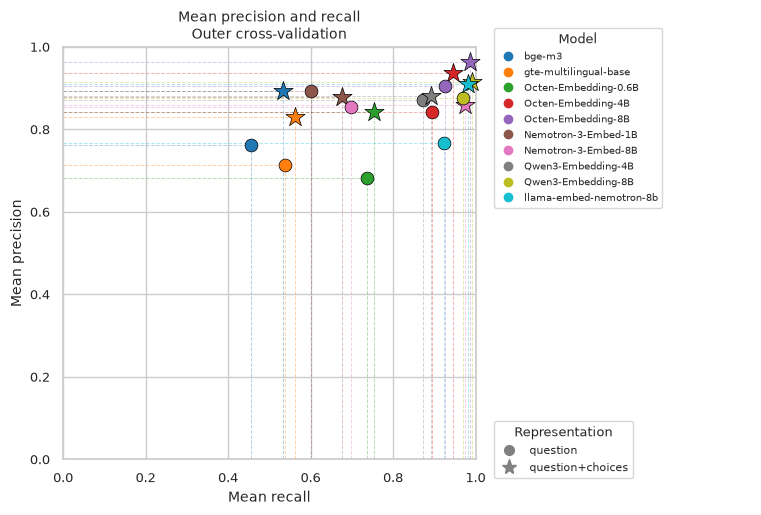

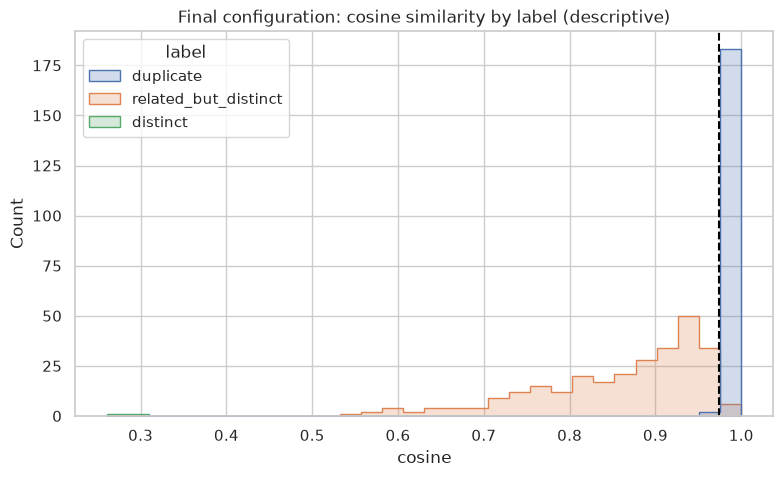

,analysis,tp,fp,tn,fn,precision,recall,f1,mcc
0,final semantic / descriptive,184,6,275,1,0.968421,0.994595,0.981333,0.969011
1,previously selected fuzzy baseline / descriptive,128,6,275,57,0.955224,0.691892,0.802508,0.724840


Pairs without truncation across all treatments: 466 / 466


,configuration,pairs,tp,fp,tn,fn,precision,recall,f1,mcc
0,Nemotron-3-Embed-1B-BF16__question,466,111,12,269,74,0.902439,0.600000,0.720779,0.618621
1,Nemotron-3-Embed-1B-BF16__question_choices,466,121,4,277,64,0.968000,0.654054,0.780645,0.706584
2,Nemotron-3-Embed-8B-BF16__question,466,137,21,260,48,0.867089,0.740541,0.798834,0.688151
3,Nemotron-3-Embed-8B-BF16__question_choices,466,184,30,251,1,0.859813,0.994595,0.922306,0.871692
4,Octen-Embedding-0.6B__question,466,154,70,211,31,0.687500,0.832432,0.753056,0.571236
5,Octen-Embedding-0.6B__question_choices,466,139,20,261,46,0.874214,0.751351,0.808140,0.701929
6,Octen-Embedding-4B__question,466,164,23,258,21,0.877005,0.886486,0.881720,0.803185
7,Octen-Embedding-4B__question_choices,466,177,12,269,8,0.936508,0.956757,0.946524,0.910834
8,Octen-Embedding-8B__question,466,174,18,263,11,0.906250,0.940541,0.923077,0.871278
9,Octen-Embedding-8B__question_choices,466,184,6,275,1,0.968421,0.994595,0.981333,0.969011


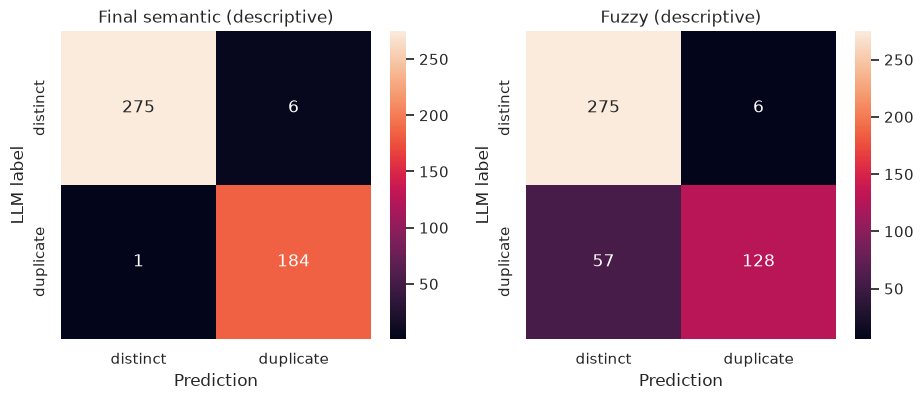

**FP: examples farthest from the threshold**

,pair_key,label,cosine,left_question,left_choices,right_question,right_choices
244,52e377dc32e1a3935888d39f631f3221f198e44e7cbffc82afa322a44e8162dc::63b8fbc566103be2d2e007bbdc4815ef3d555435...,related_but_distinct,0.985146,Campeonato de lógica O diretor de uma escola precisa selecionar três bons alunos para participar de um cam...,"[""F."", ""G."", ""K."", ""L."", ""M.""]",Campeonato de lógica O diretor de uma escola precisa selecionar três bons alunos para participar de um cam...,"[""F."", ""G."", ""K."", ""L."", ""M.""]"
337,7edaaf0ad464044c0f6305e61dcb43a5c0afab9ab455c142e0fe9f041e8d8b91::f7636e72b9f07a6b79da8dcff9b5280e110c4d32...,related_but_distinct,0.983857,"Programa de Recreio Durante os Cursos de Programação da OBI, para os melhores classificados da Modalidade ...","[""A Turma A participa de boliche na sexta-feira."", ""A Turma C participa de boliche na terça-feira."", ""A Tu...","Programa de Recreio Durante os Cursos de Programação da OBI, para os melhores classificados da Modalidade ...","[""A Turma A participa de cinema na quinta-feira."", ""A Turma B não faz compras na sexta-feira."", ""A Turma C..."
163,3094453fa097da265fed41112e74f7e9e184b282ec5f3b3c5fa55f764622428a::d0d8b192f4b8d1b2c846c1e1ff7f5b536c3a756a...,related_but_distinct,0.983442,"Rali de Informática O professor de informática da escola inventou uma nova modalidade de competição, que e...","[""Beto é o terceiro"", ""Chico é o segundo"", ""Davi é o primeiro"", ""Enzo é o primeiro"", ""Enzo é o quarto""]","Rali de Informática O professor de informática da escola inventou uma nova modalidade de competição, que e...","[""Beto, Chico, Enzo, Davi"", ""Chico, Beto, Enzo, Davi"", ""Chico, Enzo, Beto, Chico"", ""Davi, Beto, Enzo, Chic..."
308,70ed59f054b329f8b8a32a5f817cb979364f60d1bd86c92728b7688c9d4ae648::e9b0e10229be362e470c2c35db333d2e5c841923...,related_but_distinct,0.979982,"Peruas da prefeitura A cada dia, cinco meninas – Fernanda, Giulia, Helena, Joice e Karina – e quatro menin...","[""Alberto"", ""Caio"", ""Davi"", ""Fernanda"", ""Helena""]","Peruas da prefeitura A cada dia, cinco meninas – Fernanda, Giulia, Helena, Joice e Karina – e quatro menin...","[""Alberto"", ""Fernanda"", ""Giulia"", ""Joice"", ""Karina""]"
170,35942e0a1362ec7f4b8220eb18e620d8a55e1fd0c4681cc67d4475aea7685490::557cd501c961f144f380045d529d90aec357ae90...,related_but_distinct,0.979362,No Restaurante Italiano Sandro sempre que vai ao restaurante italiano põe em sua macarronada no mínimo doi...,"[""molho 1, molho 2, V, W, Y"", ""molho 1, molho 2, V, X, Y"", ""molho 1, molho 3, U, V, W, Z"", ""molho 2, molho...",No Restaurante Italiano Sandro sempre que vai ao restaurante italiano põe em sua macarronada no mínimo doi...,"[""molho 3"", ""W"", ""X"", ""Y"", ""Z""]"
151,2c0c60ab2f520ce81fed0d782aaa0289e3e215ce5e284470e48355fd43d980ca::2c675745e693c43f08c32dd430eacbdb8dcd8f95...,related_but_distinct,0.975946,Meu Primeiro Computador Daniel ganhou seu primeiro computador pessoal e está aprendendo a trabalhar com el...,"[""\""10 11 9\""."", ""\""10 10 10 8\""."", ""\""10 10 11 9\""."", ""\""10 8 7 9\""."", ""\""10 11 10 9\"".""]",Meu Primeiro Computador Daniel ganhou seu primeiro computador pessoal e está aprendendo a trabalhar com el...,"[""\""0 10 6\""."", ""\""10 0 4\""."", ""\""0 10 4\""."", ""\""10 0 6\""."", ""\""0 10 8\"".""]"


**FN: examples farthest from the threshold**

,pair_key,label,cosine,left_question,left_choices,right_question,right_choices
345,83c0debb991a75060ad392ee1332bf433d21f57821f32043687538ff3e1501c7::e69fac49738a27cb8b21f2d0ef32264755c4b531...,duplicate,0.963354,"Em relação à aplicação adequada das técnicas de Inteligência Artificial, avalie as afirmações a seguir. I....","[""I, apenas."", ""III, apenas."", ""I e II, apenas."", ""II e III, apenas."", ""I, II e III.""]","Em relação à aplicação adequada das técnicas de Inteligência Artificial, avalie as afirmações a seguir. I....","[""I, apenas."", ""III, apenas."", ""I e II, apenas."", ""II e III, apenas."", ""I, II e III.""]"


,pairs,predicted_duplicates
label,,
distinct,2,0
duplicate,185,184
related_but_distinct,279,6


In [6]:
def save_figure(name: str) -> None:
    plt.gcf().savefig(ARTIFACT_ROOT / f"{name}.png", dpi=180, bbox_inches="tight")


mean_precision_recall = treatment_metrics.groupby("configuration", as_index=False)[["precision", "recall"]].mean()
mean_precision_recall[["model", "representation"]] = mean_precision_recall.configuration.str.rsplit("__", n=1, expand=True)
mean_precision_recall.to_csv(ARTIFACT_ROOT / "mean_precision_recall_by_model.csv", index=False)

fig = plt.figure(figsize=(7.5, 5), dpi=100, layout="constrained")
ax, legend_ax = fig.subplots(1, 2, gridspec_kw={"width_ratios": [1.6, 1]})
legend_ax.set_axis_off()
model_names = [spec["model"].split("/")[-1] for spec in MODELS]
colors = dict(zip(model_names, sns.color_palette("tab10", n_colors=len(model_names)), strict=True))
markers = {"question": "o", "question_choices": "*"}
for model_name in model_names:
    for representation, marker in markers.items():
        point = mean_precision_recall.loc[
            mean_precision_recall.model.eq(model_name)
            & mean_precision_recall.representation.eq(representation)
        ].iloc[0]
        ax.hlines(point.precision, 0, point.recall, color=colors[model_name],
                  linestyle="--", linewidth=0.7, alpha=0.35, zorder=1)
        ax.vlines(point.recall, 0, point.precision, color=colors[model_name],
                  linestyle="--", linewidth=0.7, alpha=0.35, zorder=1)
        ax.scatter(point.recall, point.precision, color=colors[model_name], marker=marker,
                   s=85 if marker == "o" else 210, edgecolors="black", linewidths=0.5,
                   zorder=3, clip_on=False)
model_handles = [Line2D([], [], color=colors[name], marker="o", linestyle="",
                        label=name.removesuffix("-BF16")) for name in model_names]
model_legend = legend_ax.legend(
    handles=model_handles, title="Model", loc="upper left",
    fontsize=7.5, title_fontsize=9, borderaxespad=0, handletextpad=0.5)
legend_ax.add_artist(model_legend)
representation_legend = legend_ax.legend(
    handles=[Line2D([], [], color="gray", marker=marker, linestyle="",
                    markersize=7 if marker == "o" else 11, label=label)
             for marker, label in [("o", "question"), ("*", "question+choices")]],
    title="Representation", loc="lower left", fontsize=8,
    title_fontsize=9, borderaxespad=0)
ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="Mean recall", ylabel="Mean precision",
       title="Mean precision and recall\nOuter cross-validation")
ax.set_aspect("equal", adjustable="box")
ax.title.set_fontsize(10)
ax.tick_params(labelsize=9)
ax.xaxis.label.set_size(10)
ax.yaxis.label.set_size(10)
save_figure("mean_precision_recall_by_model")
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(data=pairs.assign(cosine=selected_scores), x="cosine", hue="label",
             bins=30, element="step", stat="count", common_norm=False, ax=ax)
ax.axvline(selected_threshold, color="black", linestyle="--")
ax.set_title("Final configuration: cosine similarity by label (descriptive)")
save_figure("selected_score_distribution")
plt.show()

summary = pd.DataFrame([
    {"analysis": "final semantic / descriptive", **metrics(y, selected_predictions)},
    {"analysis": "previously selected fuzzy baseline / descriptive", **metrics(y, fuzzy.prediction)},
])
display(summary)
summary.to_csv(ARTIFACT_ROOT / "descriptive_comparison.csv", index=False)

truncated_ids = set(token_audit.loc[token_audit.truncated, "id"])
common_mask = ~(pairs.left_id.isin(truncated_ids) | pairs.right_id.isin(truncated_ids))
print(f"Pairs without truncation across all treatments: {common_mask.sum()} / {len(pairs)}")
if common_mask.any():
    comparison = []
    for slug in configurations:
        threshold = best_threshold(scores[slug].to_numpy(), y)
        comparison.append({"configuration": slug, "pairs": int(common_mask.sum()),
                           **metrics(y[common_mask], scores.loc[common_mask, slug] >= threshold)})
    common_results = pd.DataFrame(comparison)
    common_results.to_csv(ARTIFACT_ROOT / "untruncated_descriptive_metrics.csv", index=False)
    display(common_results)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, name, predictions in zip(axes, ("Final semantic (descriptive)", "Fuzzy (descriptive)"),
                                (selected_predictions, fuzzy.prediction)):
    m = metrics(y, predictions)
    sns.heatmap([[m["tn"], m["fp"]], [m["fn"], m["tp"]]], annot=True, fmt="d",
                xticklabels=["distinct", "duplicate"], yticklabels=["distinct", "duplicate"], ax=ax)
    ax.set(title=name, xlabel="Prediction", ylabel="LLM label")
save_figure("confusion_matrices")
plt.show()

errors = pairs.assign(cosine=selected_scores, prediction=selected_predictions,
    fuzzy_prediction=fuzzy.prediction,
    error=np.where(selected_predictions & ~y, "FP", np.where(~selected_predictions & y, "FN", "correct")))
errors["threshold_distance"] = abs(errors.cosine - selected_threshold)
errors.to_parquet(ARTIFACT_ROOT / "pair_audit.parquet", index=False)
for kind in ("FP", "FN"):
    display(Markdown(f"**{kind}: examples farthest from the threshold**"))
    display(errors[errors.error.eq(kind)].sort_values("threshold_distance", ascending=False).head(8)[[
        "pair_key", "label", "cosine", "left_question", "left_choices", "right_question", "right_choices"]])
display(errors.groupby("label").agg(pairs=("pair_key", "size"), predicted_duplicates=("prediction", "sum")))

## 8. SemDeDup in NeMo Curator 1.3.0

We run the actual workflow on the selected configuration's unique items, using
1, 8, and 32 clusters, seed 42, and `which_to_keep="hard"` (farthest from the center first).
The workflow uses **RayActorPoolExecutor for K-means** and **XennaExecutor for pairwise comparisons**.
`eps = 1 − threshold`, and the installed rule is `cosine_sim_score >= 1 − eps`.

NeMo stores each item's highest cosine similarity with preceding items in the ordering,
not just with retained items. `max_id` may itself be marked for removal. These relations
therefore do not guarantee retained representatives. A pair's label also cannot be
inferred from the removal of one of its endpoints.

K-means sees all unlabeled embeddings in this descriptive stage. Its results are not
used to select the winner of the outer evaluation. A single cluster is a control
without losses at cluster boundaries; this small sample does not measure scalability.

In [7]:
selected_embeddings = np.load(embedding_paths[selected_slug], allow_pickle=False)
nemo_root = ARTIFACT_ROOT / "nemo" / digest({"slug": selected_slug, "threshold": selected_threshold,
    "embedding_sha256": hashlib.sha256(embedding_paths[selected_slug].read_bytes()).hexdigest()})[:16]
nemo_root.mkdir(parents=True, exist_ok=True)
embedding_input = nemo_root / "input"
embedding_input.mkdir(exist_ok=True)
input_file = embedding_input / "embeddings.parquet"
if not input_file.exists():
    pd.DataFrame({"id": items.id, "embeddings": list(selected_embeddings)}).to_parquet(input_file, index=False)


def parquet_files(directory: Path) -> pd.DataFrame:
    files = sorted(directory.rglob("*.parquet"))
    if not files:
        return pd.DataFrame()
    return pd.concat([pd.read_parquet(path) for path in files], ignore_index=True)


cluster_rows, removal_tables = [], []
for n_clusters in CLUSTER_COUNTS:
    run_dir = nemo_root / f"k{n_clusters}"
    complete = run_dir / "complete.json"
    if not complete.exists():
        if not RUN_COMPUTE:
            raise FileNotFoundError(f"Missing NeMo cache: {run_dir}")
        import ray
        from nemo_curator.backends.ray_actor_pool import RayActorPoolExecutor
        from nemo_curator.backends.xenna import XennaExecutor
        from nemo_curator.core.client import RayClient
        from nemo_curator.stages.deduplication.semantic import SemanticDeduplicationWorkflow

        if ray.is_initialized() or os.environ.get("RAY_ADDRESS"):
            raise RuntimeError("Close the existing Ray session before starting this isolated experiment.")
        # The external cluster survives each executor's internal ray.shutdown().
        with RayClient(num_gpus=1, num_cpus=8, include_dashboard=False, object_store_memory=2 * 1024**3):
            started = time.perf_counter()
            workflow = SemanticDeduplicationWorkflow(
                input_path=str(embedding_input), output_path=str(run_dir / "results"),
                cache_path=str(run_dir / "cache"), n_clusters=n_clusters,
                id_field="id", embedding_field="embeddings", embedding_dim=selected_embeddings.shape[1],
                input_filetype="parquet", random_state=SEED, which_to_keep="hard",
                pairwise_batch_size=1024, eps=1 - selected_threshold, verbose=False,
            )
            workflow.run(kmeans_executor=RayActorPoolExecutor(), pairwise_executor=XennaExecutor())
            write_json(complete, {"seconds": time.perf_counter() - started, "n_clusters": n_clusters})
    clusters = pd.read_parquet(run_dir / "cache/kmeans_results")
    relations = parquet_files(run_dir / "cache/pairwise_results")
    removed = parquet_files(run_dir / "results/duplicates")
    assert len(clusters) == len(items) and clusters.id.nunique() == len(items)
    assert set(clusters.id) == set(items.id)
    assert len(relations) == len(items) and relations.id.nunique() == len(items)
    assignments = clusters.set_index("id").centroid
    same_cluster = pairs.left_id.map(assignments).eq(pairs.right_id.map(assignments)).to_numpy()
    candidate_predictions = same_cluster & selected_predictions
    removed_ids = set(removed.id) if len(removed) else set()
    expected_removed = set(relations.loc[relations.cosine_sim_score >= selected_threshold, "id"])
    assert removed_ids == expected_removed
    audit = relations[relations.id.isin(removed_ids)].copy()
    audit["max_id_also_removed"] = audit.max_id.isin(removed_ids)
    audit["n_clusters"] = n_clusters
    assert not audit.id.eq(audit.max_id).any()
    if len(audit):
        a, b = audit.id.map(item_index).to_numpy(), audit.max_id.map(item_index).to_numpy()
        direct_scores = np.einsum("ij,ij->i", selected_embeddings[a], selected_embeddings[b])
        assert np.allclose(audit.cosine_sim_score, direct_scores, atol=2e-5)
    audit.to_parquet(run_dir / "removal_audit.parquet", index=False)
    removal_tables.append(audit)
    pair_cluster_audit = pairs[["pair_key", "label"]].assign(same_cluster=same_cluster,
                                                           candidate_prediction=candidate_predictions)
    pair_cluster_audit.to_parquet(run_dir / "pair_cluster_audit.parquet", index=False)
    cluster_rows.append({"n_clusters": n_clusters, "positive_pairs_split": int(np.sum(y & ~same_cluster)),
        "positive_pair_cluster_recall": float(np.mean(same_cluster[y])),
        "items_marked_for_removal": len(removed_ids), "max_id_also_removed": int(audit.max_id_also_removed.sum()),
        **metrics(y, candidate_predictions), **read_json(complete)})
    if n_clusters == 1:
        assert same_cluster.all() and np.array_equal(candidate_predictions, selected_predictions)

cluster_metrics = pd.DataFrame(cluster_rows)
cluster_metrics.to_csv(ARTIFACT_ROOT / "nemo_cluster_diagnostics.csv", index=False)
removal_audit = pd.concat(removal_tables, ignore_index=True)
display(cluster_metrics)
display(removal_audit.head(15))

2026-09-23 18:07:04.883 | INFO     | nemo_curator.core.utils:init_cluster:212 - Ray start command: ray start --head --node-ip-address 10.100.0.123 --port 6379 --metrics-export-port 8082 --dashboard-host 127.0.0.1 --dashboard-port 8265 --ray-client-server-port 10001 --temp-dir /tmp/ray --object-store-memory 2147483648 --disable-usage-stats --num-gpus 1 --num-cpus 8 --block


2026-09-23 18:07:09,636	INFO usage_lib.py:448 -- Usage stats collection is disabled.
2026-09-23 18:07:09,637	INFO scripts.py:1042 -- Local node IP: 10.100.0.123
2026-09-23 18:07:23,990	SUCC scripts.py:1081 -- --------------------
2026-09-23 18:07:23,991	SUCC scripts.py:1082 -- Ray runtime started.
2026-09-23 18:07:23,991	SUCC scripts.py:1083 -- --------------------
2026-09-23 18:07:23,991	INFO scripts.py:1085 -- Next steps
2026-09-23 18:07:23,991	INFO cli_output_helpers.py:16 -- Note: The following commands are intended for use on
2026-09-23 18:07:23,991	INFO cli_output_helpers.py:17 -- the head node or within the cluster network.
2026-09-23 18:07:23,991	INFO scripts.py:1089 -- To add another node to this Ray cluster, run
2026-09-23 18:07:23,991	INFO scripts.py:1092 --   ray start --address='10.100.0.123:6379'
2026-09-23 18:07:23,991	INFO scripts.py:1103 -- To connect to this Ray cluster:
2026-09-23 18:07:23,991	INFO scripts.py:1105 -- import ray
2026-09-23 18:07:23,991	INFO scripts.py

2026-09-23 18:07:28.671 | WARNING  | nemo_curator.stages.deduplication.semantic.workflow:_validate_config:207 - n_clusters=1 is less than 1000. For large datasets, this may result in out-of-memory errors since each cluster must fit in memory. Consider using n_clusters >= 1000 for large datasets.


2026-09-23 18:07:28.682 | INFO     | nemo_curator.stages.deduplication.semantic.workflow:_log_configuration:329 - ============================================================


2026-09-23 18:07:28.683 | INFO     | nemo_curator.stages.deduplication.semantic.workflow:_log_configuration:330 - SEMANTIC DEDUPLICATION WORKFLOW CONFIGURATION


...

2026-09-23 18:13:12.204 | INFO     | nemo_curator.stages.deduplication.semantic.workflow:run:420 - Similarity threshold used: 0.974 (eps=0.02629488706588745)


2026-09-23 18:13:12.205 | SUCCESS  | nemo_curator.stages.deduplication.semantic.workflow:run:425 - ============================================================


2026-09-23 18:13:15.828 | INFO     | nemo_curator.core.client:stop:205 - NeMo Curator has stopped the Ray cluster it started by killing the Ray GCS process. It is advised to wait for a few seconds before running any Ray commands to ensure Ray can cleanup other processes.If you are seeing any Ray commands like `ray status` failing, please ensure /tmp/ray/ray_current_cluster has correct information.


,n_clusters,positive_pairs_split,positive_pair_cluster_recall,items_marked_for_removal,max_id_also_removed,tp,fp,tn,fn,precision,recall,f1,mcc,seconds
0,1,0,1.0,219,37,184,6,275,1,0.968421,0.994595,0.981333,0.969011,101.344399
1,8,0,1.0,219,39,184,6,275,1,0.968421,0.994595,0.981333,0.969011,94.117627
2,32,0,1.0,220,41,184,6,275,1,0.968421,0.994595,0.981333,0.969011,94.028438


,id,max_id,cosine_sim_score,max_id_also_removed,n_clusters
0,7de9a980b6fe6230b58bbee07d010ef4150aa4e9aa5bb5843988586fed8c7b2a,7d95691d8638050ae0ced59588e5615f82a1e7ed5515fa39d39e3ef93da4363f,0.998859,False,1
1,651de9511cab1a1f825082e7e892be71ae9e701c8177ac65b1ef984e54c5bd16,618c20274e77d612cd6dcfaceeb5cb5ca643e1ddcb1de264f0153ebe4da1d8b7,0.998177,False,1
2,00f3e3d8c15b999d7a01eb08d9ca11e9f209110485cc4a4f5359e71c4b8ef503,5f1ad62fe746e4a0a2aef2ba9f892ca73b9655f27174598ef2406f5a21ad02fe,0.995245,False,1
3,ddd773c976edc7c1fa3f52da72902f824d45552f782842f0fb37017b7cedb9ca,1d47e1d6dbaac3494debf3600ef8178b9e6eb74682cb9d093eface829ee62528,0.999434,False,1
4,c6b7a7d7284969514f72548aa3f9aadbc072937fbd91644095534b308030001f,618c20274e77d612cd6dcfaceeb5cb5ca643e1ddcb1de264f0153ebe4da1d8b7,0.995187,False,1
5,db17281d098d476782eea4334d2abe6f8f50ea862d6fa481d4841b265e5c8907,f2870a1d192aa671c458e3a5ca154d6d9286ba8a78a0d0537ade76e305bf9c0f,0.995030,False,1
6,5dbe800443b376b557d509d166cefb557ef7c2ecb5eb5ded941b979a5d85f680,c0e05bb4c72cd7cdf208d0a86e4e89203e80dd7f895b88b12a0883859d4dea3f,0.998522,False,1
7,193b0f089c007b4c19c983a413d74bc37fbcb42dd59c8bde9890bbc4b5a9979b,a200c45743f844b8a2dc447f2983c60305df397d36d60a73dbecd22153277b04,0.990746,False,1
8,c91fa55cc10b28c300ae02eb6ab78788ee69cf22d95b98d4a1e3e6a1005952ea,4c1d4b4e1307464a561061951cf6321d1a95ea93648b98dce7dae509d24b8e2a,0.997810,False,1
9,ab10ca7a4d726973e0bfcc8bca0c76b073238a2950060fe47f553dc65c60f1ff,9ec10e22c89456384f6f1c2da3a537f770369a759eed6df10356c5f29f3880b9,0.999481,False,1


## 9. Interpretation and traceability

- The winner and its threshold are provisional for this panel. The 466 pairs were
  enriched through fuzzy search; they are not random corpus pairs and do not quantify
  semantic duplicates missed by lexical retrieval.
- Labels were produced by an LLM. Cross-validation controls some selection optimism
  and item sharing, but does not validate labels or remove sampling bias.
- Only two negatives are `distinct`; negative examples are dominated by
  `related_but_distinct`. Robust conclusions about the former class are unsupported.
- Per-treatment and truncation metrics are diagnostic. Selecting new prompts or
  hyperparameters using the outer test results would compromise their independence.
- False positives may reflect shared passages, numerical changes, negation, or a
  different target. Review examples before proposing automatic removal.
- The NeMo workflow does not publish a deduplicated corpus. Before production,
  evaluate new semantic candidates and define a representative-selection policy.
- Recorded times measure inference or workflow execution, excluding downloads;
  they are not rigorous throughput benchmarks. GPUs, libraries, and small numerical
  differences may affect ties.

## 10. Results analysis

Summary computed from this run's artifacts.

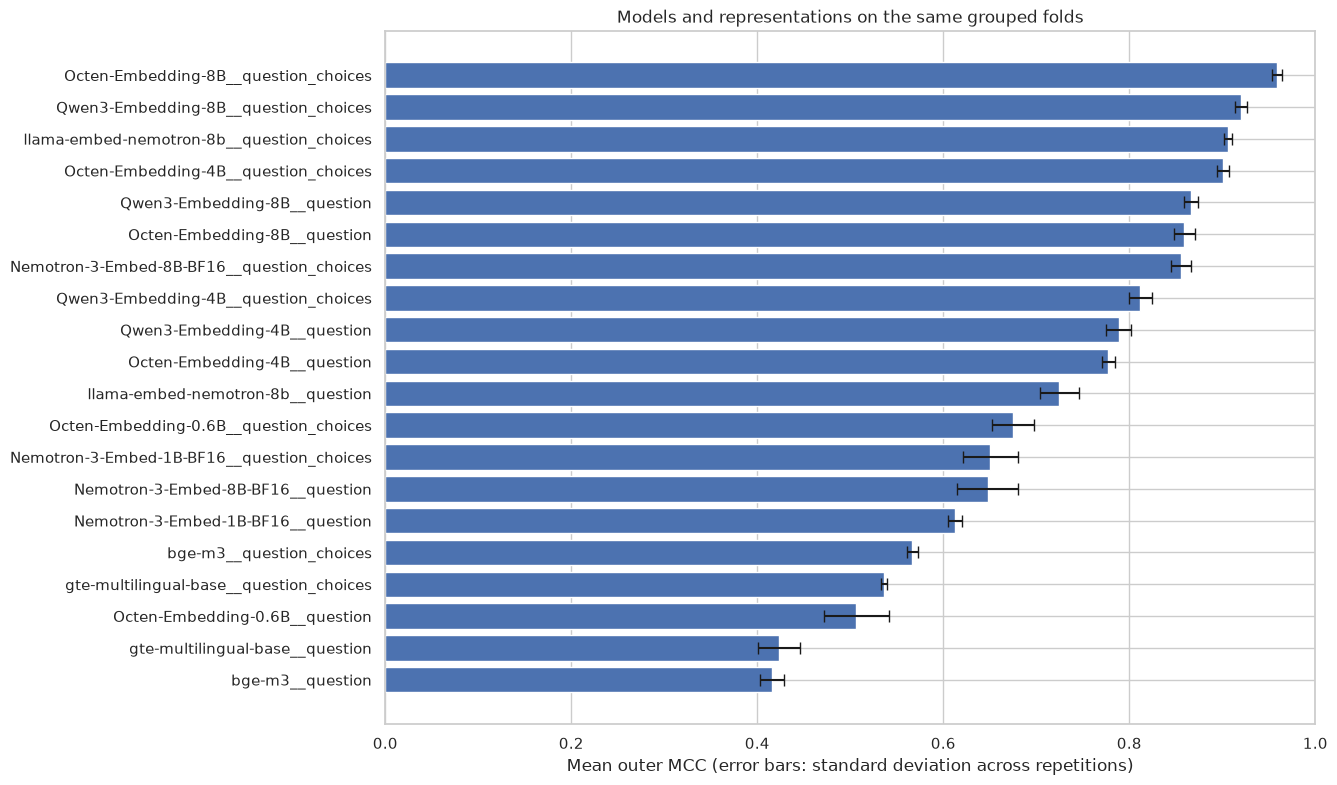

,left_exam,right_exam,label,pairs
0,OBI,OBI,related_but_distinct,6


**Duplicates missed in at least one outer repetition:**

,pair_key,oof_error_rate,cosine,left_question,left_choices,right_question,right_choices
345,83c0debb991a75060ad392ee1332bf433d21f57821f32043687538ff3e1501c7::e69fac49738a27cb8b21f2d0ef32264755c4b531...,1.0,0.963354,"Em relação à aplicação adequada das técnicas de Inteligência Artificial, avalie as afirmações a seguir. I....","[""I, apenas."", ""III, apenas."", ""I e II, apenas."", ""II e III, apenas."", ""I, II e III.""]","Em relação à aplicação adequada das técnicas de Inteligência Artificial, avalie as afirmações a seguir. I....","[""I, apenas."", ""III, apenas."", ""I e II, apenas."", ""II e III, apenas."", ""I, II e III.""]"
457,e3437c0fc0ad76ff6fa91b740c8ea64310de2fc6efdeb67390d3a1c60f57cb04::eea2e43b33128a0aab3d43e5d6ef2fe91c0a2628...,1.0,0.973739,"O sistema de tarifação de energia elétrica funciona com base em três bandeiras. Na bandeira verde, as cond...","[""II, apenas."", ""III, apenas."", ""I e II, apenas."", ""I e III, apenas."", ""I, II e III.""]","O sistema de tarifação de energia elétrica funciona com base em três bandeiras. Na bandeira verde, as cond...","[""II, apenas."", ""III, apenas."", ""I e II, apenas."", ""I e III, apenas."", ""I, II e III.""]"
175,373a8e45283c0e744a8b69b09dc7a045e0a1a130d8872e397df2a796ee849bdb::77f77814329b1b9b72cc70c5025997b516b41cb5...,0.2,0.976615,"O _diabetes mellitus_ é uma síndrome que constitui um grave problema de saúde pública no Brasil, com estim...","[""considerar prioritariamente exercícios físicos realizados no ambiente aquático, tendo em vista que o gas...","O _diabetes mellitus_ é uma síndrome que constitui um grave problema de saúde pública no Brasil, com estim...","[""considerar prioritariamente exercícios físicos realizados no ambiente aquático, tendo em vista que o gas..."
259,58e715e3e372a7e951997ecd6093bb11050d6bcef0e8496a0c7b9a416071322d::fea9a2c468fe7bbf35c8ca53ff54377f26dbe6f2...,0.1,0.984599,Compra na Feira A mãe de Lucas pediu-lhe que fosse à feira e comprasse alguns ingredientes para o almoço. ...,"[""3"", ""4"", ""5"", ""6"", ""7""]",Compras na Feira A mãe de Lucas pediu-lhe que fosse à feira e comprasse alguns ingredientes para o almoço....,"[""Couve, Banana e Cebola."", ""Cebola, Alho e Banana."", ""Couve, Pêra e Alho."", ""Couve, Cebola e Alho."", ""Som..."
165,31395ee1db06859d5dba858c2f7136ed03c7e16bdb21299b67463757c77b9af5::8ca4b8b1603a7992756175577c94c65bddeb1a50...,0.1,0.980116,"Show Oito amigas - Alda, Bia, Flora, Gabi, Júlia, Lia, Mara e Sula – vão se apresentar no show de talentos...","[""Gabi"", ""Flora"", ""Lia"", ""Sula"", ""Alda""]","Show Oito amigas – Alda, Bia, Flora, Gabi, Júlia, Lia, Mara e Sula – vão se apresentar no show de talentos...","[""Gabi"", ""Flora"", ""Lia"", ""Sula"", ""Alda""]"
358,8987859594afe4f385f792b98504ea3134663246225e180abec4cc85c11fd2c5::8e8573abcd0514eb2c7ec0f5192e7fa04db75ed0...,0.1,0.976937,"Casa Blanca. Y allí, con sendos ""cuarto de libra"" en la mano, discutieron y llegaron a un acuerdo con el t...","[""Sanciones - penas que una ley o un reglamento establece para sus infractores. (línea 14)"", ""Estima - con...","Casa Blanca. Y allí, con sendos ""cuarto de libra"" en la mano, discutieron y llegaron a un acuerdo con el t...","[""Sanciones - penas que una ley o un reglamento establece para sus infractores. (línea 14)"", ""Estima - con..."
366,8dcf10b0ca4ccc5bc7a78db3b3e64e3f28aab5b4f649acfcee79c76936b00afb::fa70ecd19508b32150a4b4ecd973aee499c63f54...,0.1,0.978362,"O sistema de tarifação de energia elétrica funciona com base em três bandeiras. Na bandeira verde, as cond...","[""II, apenas."", ""III, apenas."", ""I e II, apenas."", ""I e III, apenas."", ""I, II e III.""]","O sistema de tarifação de energia elétrica funciona com base em três bandeiras. Na bandeira verde, as cond...","[""II, apenas."", ""III, apenas."", ""I e II, apenas."", ""I e III, apenas."", ""I, II e III.""]"


# Semantic deduplication results analysis

Run: 2026-09-23T21:13:16.810922+00:00. Annotation SHA-256: `a51cbf1099b969b0573abd104184bf91874df64f1dc09bbb5a418ac2110290a6`.
Panel: 466 pairs, 837 items, and 373 groups.

## Main result

The recommended configuration is **`Octen-Embedding-8B__question_choices`**, with a final cosine threshold
of **0.973705** (`eps=0.026295`). It was selected
in **48 of 50 outer folds**.

The complete selection procedure achieved a mean outer MCC of **0.955**,
precision of **96.0%**, recall of **98.6%**,
and F1 of **97.3%**. The standard deviation of MCC across
repetitions was 0.0102; this measures sensitivity to splits,
not a confidence interval.

| configuration | mcc | precision | recall | f1 |
| --- | --- | --- | --- | --- |
| Octen-Embedding-8B__question_choices | 0.959 | 96.5% | 98.6% | 97.5% |
| Qwen3-Embedding-8B__question_choices | 0.920 | 91.6% | 99.1% | 95.2% |
| llama-embed-nemotron-8b__question_choices | 0.906 | 91.0% | 98.1% | 94.4% |
| Octen-Embedding-4B__question_choices | 0.901 | 93.6% | 94.4% | 94.0% |
| Qwen3-Embedding-8B__question | 0.867 | 87.5% | 97.0% | 92.0% |
| Octen-Embedding-8B__question | 0.859 | 90.5% | 92.7% | 91.6% |
| Nemotron-3-Embed-8B-BF16__question_choices | 0.855 | 85.9% | 97.5% | 91.3% |
| Qwen3-Embedding-4B__question_choices | 0.812 | 88.2% | 89.2% | 88.7% |
| Qwen3-Embedding-4B__question | 0.789 | 87.2% | 87.4% | 87.2% |
| Octen-Embedding-4B__question | 0.777 | 84.3% | 89.5% | 86.8% |
| llama-embed-nemotron-8b__question | 0.725 | 76.8% | 92.3% | 83.8% |
| Octen-Embedding-0.6B__question_choices | 0.674 | 84.2% | 75.3% | 79.5% |
| Nemotron-3-Embed-1B-BF16__question_choices | 0.650 | 87.8% | 67.6% | 76.2% |
| Nemotron-3-Embed-8B-BF16__question | 0.648 | 85.5% | 69.8% | 76.8% |
| Nemotron-3-Embed-1B-BF16__question | 0.612 | 89.3% | 60.2% | 71.9% |
| bge-m3__question_choices | 0.567 | 89.4% | 53.4% | 66.9% |
| gte-multilingual-base__question_choices | 0.536 | 83.0% | 56.1% | 67.0% |
| Octen-Embedding-0.6B__question | 0.506 | 68.3% | 73.7% | 70.7% |
| gte-multilingual-base__question | 0.423 | 71.4% | 53.9% | 61.4% |
| bge-m3__question | 0.416 | 76.2% | 45.5% | 56.9% |

Including answer choices changed the selected model's mean outer MCC by
**+0.100**. Full-item embeddings should be the reference
representation for further work. Truncation affected **0**
item/configuration combinations, so truncation does not explain the observed differences.
Each model uses its own input protocol, including the same task instruction for both Qwen sizes and Llama-Embed-Nemotron,
the document prefix for Octen, and the passage prefix for both Nemotron 3 sizes;
this design compares complete configurations and does not isolate model capacity
from the effect of the instruction.

## Descriptive comparison with fuzzy deduplication

The final operating point, fitted on the full panel, produced 184 true positives,
6 false positives, and 1 false negatives.
The previously selected fuzzy baseline produced 128, 6,
and 57, respectively.
The semantic approach added 56 correctly identified duplicates
and 5 false positives, while correcting 5
false positives from the fuzzy baseline.
These figures describe the same data used for final fitting; use the outer metrics
above to estimate the selection procedure's performance.

## Llama-Embed-Nemotron-8B comparison

With question text and answer choices, Nemotron achieved mean outer MCC
**0.906**, precision **91.0%**,
recall **98.1%**, and F1 **94.4%**.
Its question-only MCC was **0.725**.
Qwen with choices achieved MCC **0.920** on the same splits;
this observed difference is not a claim of statistical significance.
Nemotron with choices was selected in **0 of
50 outer folds**. The full selection procedure's metrics above
include folds that selected any of the evaluated configurations and differ from fixed-treatment metrics.

Nemotron used its official Transformers 4.51.0 implementation with eager bidirectional
attention and float32 masked mean pooling. Its isolated runtime leaves the project
versions unchanged. Full-item inference took **32.5 s**
with peak PyTorch-allocated memory of **20.6 GiB**.
Runtime comparisons include different attention and batching implementations;
they describe this experiment rather than model-only efficiency.

## Remaining errors

| left_exam | right_exam | label | pairs |
| --- | --- | --- | --- |
| OBI | OBI | related_but_distinct | 6 |

The error examples shown in the notebook contain almost identical passages with
changes in conditions or targets: daytime/nighttime attendance, restrictions on
beds and boxes, or different requested quantities. Very high cosine similarity can
coexist with a difference that determines the answer. The recommended threshold
maximizes MCC on this panel; it was not selected to guarantee a minimum precision
for automatic removal.

There are 7 positive pairs missed in at least one outer repetition.
The recurring example “Compra(s) na Feira” has numerical choices on one side and
ingredient names on the other, despite its `duplicate` label. This warrants reviewing
the extraction/annotation without automatically changing the label. Other cases near
the threshold involve bibliographic references, formatting changes, and reordered
choices. The outer-error table distinguishes these cases from the final fit, which has 1 false negatives.

## Effect of NeMo clusters

| n_clusters | positive_pairs_split | items_marked_for_removal | max_id_also_removed |
| --- | --- | --- | --- |
| 1 | 0 | 219 | 37 |
| 8 | 0 | 219 | 39 |
| 32 | 0 | 220 | 41 |

`positive_pairs_split` counts annotated duplicates that are not compared because
they fall into different clusters. `items_marked_for_removal` includes relations
between items that do not necessarily form annotated pairs; it cannot establish
removal precision. `max_id_also_removed` counts references that are also marked for
removal, confirming that `max_id` is not always a retained representative.
The single-cluster experiment is a control for this small panel, not a recommended
configuration for the full corpus.

## Cost and conclusion

On the B200, inference for the selected representation took 17.6 s,
with peak PyTorch-allocated memory of 16.2 GiB.
Timing excludes downloads and model loading; memory does not represent all memory
reserved by the process. These figures are not production benchmarks.

The selected model is the best option **among the treatments evaluated on this panel**.
The next validation should review false positives and annotate new semantic candidates
outside lexical sampling before defining a removal policy.
Labels were produced by an LLM, and groups prevent item sharing but do not guarantee
that all shared passages or similar topics are separated across folds. High recall
on this sample does not establish duplicate coverage across the full corpus.


In [8]:
# This summary is recomputed on every run; labels and models are not refitted here.
model_summary = treatment_metrics.groupby("configuration")[["mcc", "precision", "recall", "f1"]].mean().sort_values("mcc", ascending=False)
model_std = treatment_metrics.groupby("configuration").mcc.std().reindex(model_summary.index)
fig, ax = plt.subplots(figsize=(12, max(5, 0.45 * len(model_summary))))
positions = np.arange(len(model_summary))
ax.barh(positions, model_summary.mcc, xerr=model_std, capsize=4)
ax.set_yticks(positions, model_summary.index)
ax.invert_yaxis()
ax.set(xlim=(min(0, float((model_summary.mcc - model_std).min()) - 0.02), 1), xlabel="Mean outer MCC (error bars: standard deviation across repetitions)",
       title="Models and representations on the same grouped folds")
save_figure("model_comparison")
plt.show()

exam_metadata = pd.read_csv(ANNOTATION_PATH, usecols=["pair_key", "left_exam", "right_exam"])
error_details = errors.merge(exam_metadata, on="pair_key", validate="one_to_one")
false_positives = error_details[error_details.error.eq("FP")]
false_positive_groups = false_positives.groupby(["left_exam", "right_exam", "label"]).size().reset_index(name="pairs")
false_positive_groups.to_csv(ARTIFACT_ROOT / "false_positives_by_exam.csv", index=False)
display(false_positive_groups)
oof_rates = outer_predictions.assign(error=lambda frame: frame.label.ne(frame.prediction)).groupby("pair_key").agg(
    oof_error_rate=("error", "mean"), oof_positive_rate=("prediction", "mean"))
oof_audit = error_details.merge(oof_rates, on="pair_key", validate="one_to_one")
oof_audit.to_parquet(ARTIFACT_ROOT / "out_of_fold_pair_audit.parquet", index=False)
oof_false_negatives = oof_audit[oof_audit.label.eq("duplicate") & oof_audit.oof_error_rate.gt(0)]
display(Markdown("**Duplicates missed in at least one outer repetition:**"))
display(oof_false_negatives.sort_values("oof_error_rate", ascending=False)[[
    "pair_key", "oof_error_rate", "cosine", "left_question", "left_choices", "right_question", "right_choices"]])

selected_full = metrics(y, selected_predictions)
fuzzy_full = metrics(y, fuzzy.prediction)
additional = selected_predictions & ~fuzzy.prediction.to_numpy()
corrected = ~selected_predictions & fuzzy.prediction.to_numpy() & ~y
selected_counts = outer_results.configuration.value_counts()
no_truncation = not token_audit.truncated.any()


def markdown_table(frame: pd.DataFrame) -> str:
    header = "| " + " | ".join(map(str, frame.columns)) + " |"
    separator = "| " + " | ".join("---" for _ in frame.columns) + " |"
    rows = ["| " + " | ".join(str(value) for value in row) + " |" for row in frame.itertuples(index=False, name=None)]
    return "\n".join([header, separator, *rows])


table = model_summary.reset_index().copy()
table["mcc"] = table.mcc.map(lambda value: f"{value:.3f}")
for column in ("precision", "recall", "f1"):
    table[column] = table[column].map(lambda value: f"{value:.1%}")
cluster_table = cluster_metrics[["n_clusters", "positive_pairs_split", "items_marked_for_removal", "max_id_also_removed"]]
best_base = selected_slug.rsplit("__", 1)[0]
alternatives_effect = (
    model_summary.loc[best_base + "__question_choices", "mcc"]
    - model_summary.loc[best_base + "__question", "mcc"]
)
selected_runtime = runtime_table.set_index("slug").loc[selected_slug]
nemotron_slug = "llama-embed-nemotron-8b__question_choices"
nemotron_metrics = model_summary.loc[nemotron_slug]
nemotron_runtime = runtime_table.set_index("slug").loc[nemotron_slug]
qwen_metrics = model_summary.loc["Qwen3-Embedding-8B__question_choices"]
report = f"""# Semantic deduplication results analysis

Run: {datetime.now(timezone.utc).isoformat()}. Annotation SHA-256: `{ANNOTATION_SHA256}`.
Panel: {len(pairs)} pairs, {len(items)} items, and {pairs.group_id.nunique()} groups.

## Main result

The recommended configuration is **`{selected_slug}`**, with a final cosine threshold
of **{selected_threshold:.6f}** (`eps={1 - selected_threshold:.6f}`). It was selected
in **{selected_counts.get(selected_slug, 0)} of {len(outer_results)} outer folds**.

The complete selection procedure achieved a mean outer MCC of **{repeat_metrics.mcc.mean():.3f}**,
precision of **{repeat_metrics.precision.mean():.1%}**, recall of **{repeat_metrics.recall.mean():.1%}**,
and F1 of **{repeat_metrics.f1.mean():.1%}**. The standard deviation of MCC across
repetitions was {repeat_metrics.mcc.std():.4f}; this measures sensitivity to splits,
not a confidence interval.

{markdown_table(table)}

Including answer choices changed the selected model's mean outer MCC by
**{alternatives_effect:+.3f}**. Full-item embeddings should be the reference
representation for further work. Truncation affected **{int(token_audit.truncated.sum())}**
item/configuration combinations, so truncation does not explain the observed differences.
Each model uses its own input protocol, including the same task instruction for both Qwen sizes and Llama-Embed-Nemotron,
the document prefix for Octen, and the passage prefix for both Nemotron 3 sizes;
this design compares complete configurations and does not isolate model capacity
from the effect of the instruction.

## Descriptive comparison with fuzzy deduplication

The final operating point, fitted on the full panel, produced {selected_full['tp']} true positives,
{selected_full['fp']} false positives, and {selected_full['fn']} false negatives.
The previously selected fuzzy baseline produced {fuzzy_full['tp']}, {fuzzy_full['fp']},
and {fuzzy_full['fn']}, respectively.
The semantic approach added {int(np.sum(additional & y))} correctly identified duplicates
and {int(np.sum(additional & ~y))} false positives, while correcting {int(np.sum(corrected))}
false positives from the fuzzy baseline.
These figures describe the same data used for final fitting; use the outer metrics
above to estimate the selection procedure's performance.

## Llama-Embed-Nemotron-8B comparison

With question text and answer choices, Nemotron achieved mean outer MCC
**{nemotron_metrics.mcc:.3f}**, precision **{nemotron_metrics.precision:.1%}**,
recall **{nemotron_metrics.recall:.1%}**, and F1 **{nemotron_metrics.f1:.1%}**.
Its question-only MCC was **{model_summary.loc['llama-embed-nemotron-8b__question', 'mcc']:.3f}**.
Qwen with choices achieved MCC **{qwen_metrics.mcc:.3f}** on the same splits;
this observed difference is not a claim of statistical significance.
Nemotron with choices was selected in **{selected_counts.get(nemotron_slug, 0)} of
{len(outer_results)} outer folds**. The full selection procedure's metrics above
include folds that selected any of the evaluated configurations and differ from fixed-treatment metrics.

Nemotron used its official Transformers 4.51.0 implementation with eager bidirectional
attention and float32 masked mean pooling. Its isolated runtime leaves the project
versions unchanged. Full-item inference took **{nemotron_runtime.seconds:.1f} s**
with peak PyTorch-allocated memory of **{nemotron_runtime.peak_gpu_gib:.1f} GiB**.
Runtime comparisons include different attention and batching implementations;
they describe this experiment rather than model-only efficiency.

## Remaining errors

{markdown_table(false_positive_groups)}

The error examples shown in the notebook contain almost identical passages with
changes in conditions or targets: daytime/nighttime attendance, restrictions on
beds and boxes, or different requested quantities. Very high cosine similarity can
coexist with a difference that determines the answer. The recommended threshold
maximizes MCC on this panel; it was not selected to guarantee a minimum precision
for automatic removal.

There are {len(oof_false_negatives)} positive pairs missed in at least one outer repetition.
The recurring example “Compra(s) na Feira” has numerical choices on one side and
ingredient names on the other, despite its `duplicate` label. This warrants reviewing
the extraction/annotation without automatically changing the label. Other cases near
the threshold involve bibliographic references, formatting changes, and reordered
choices. The outer-error table distinguishes these cases from the final fit, which has {selected_full["fn"]} false negatives.

## Effect of NeMo clusters

{markdown_table(cluster_table)}

`positive_pairs_split` counts annotated duplicates that are not compared because
they fall into different clusters. `items_marked_for_removal` includes relations
between items that do not necessarily form annotated pairs; it cannot establish
removal precision. `max_id_also_removed` counts references that are also marked for
removal, confirming that `max_id` is not always a retained representative.
The single-cluster experiment is a control for this small panel, not a recommended
configuration for the full corpus.

## Cost and conclusion

On the B200, inference for the selected representation took {selected_runtime.seconds:.1f} s,
with peak PyTorch-allocated memory of {selected_runtime.peak_gpu_gib:.1f} GiB.
Timing excludes downloads and model loading; memory does not represent all memory
reserved by the process. These figures are not production benchmarks.

The selected model is the best option **among the treatments evaluated on this panel**.
The next validation should review false positives and annotate new semantic candidates
outside lexical sampling before defining a removal policy.
Labels were produced by an LLM, and groups prevent item sharing but do not guarantee
that all shared passages or similar topics are separated across folds. High recall
on this sample does not establish duplicate coverage across the full corpus.
"""
(ARTIFACT_ROOT / "analysis.md").write_text(report, encoding="utf-8")
display(Markdown(report))


In [9]:
assert hashlib.sha256(ANNOTATION_PATH.read_bytes()).hexdigest() == ANNOTATION_SHA256
manifest = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(), "python": platform.python_version(),
    "specification": SPEC, "model_revisions": revisions,
    "cuda_visible_devices": os.environ["CUDA_VISIBLE_DEVICES"],
    "pairs": len(pairs), "unique_items": len(items), "groups": int(pairs.group_id.nunique()),
    "selected_configuration": selected_slug, "selected_threshold": selected_threshold,
    "outer_mean_metrics": repeat_metrics[["mcc", "precision", "recall", "f1"]].mean().to_dict(),
    "artifact_sha256": {str(p.relative_to(ARTIFACT_ROOT)): hashlib.sha256(p.read_bytes()).hexdigest()
        for p in sorted(ARTIFACT_ROOT.rglob("*")) if p.is_file() and p.name != "manifest.json"},
}
write_json(ARTIFACT_ROOT / "manifest.json", manifest)
display(Markdown(
    f"**Result:** `{selected_slug}`, threshold `{selected_threshold:.6f}`. "
    f"Mean outer MCC of the procedure: **{repeat_metrics.mcc.mean():.4f}**. "
    f"Artifacts in `{ARTIFACT_ROOT.relative_to(REPO_ROOT)}`. "
    "Review the error and cluster analyses before extrapolating to the corpus."
))

**Result:** `Octen-Embedding-8B__question_choices`, threshold `0.973705`. Mean outer MCC of the procedure: **0.9548**. Artifacts in `notebooks/output/semantic-deduplication-ablation/7e16f8554e7fb8462646`. Review the error and cluster analyses before extrapolating to the corpus.